In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('ecommerce_customers.csv')
print("Contoh data (head):")
df.head()

Contoh data (head):


,customer_id,age,gender,city,purchase_count,total_spent
0,C001,56.0,Male,Yogyakarta,9,570.88
1,C002,46.0,Female,Jakarta,4,123.94
2,C003,32.0,Female,Surabaya,1,693.28
3,C004,25.0,Female,Bandung,4,397.81
4,C005,38.0,Male,Medan,1,742.08


MENGATASI NILAI KOSONG DAN OUTLIER

In [11]:
print("--- 1. Inspeksi Awal Data ---")
df.info()

--- 1. Inspeksi Awal Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     100 non-null    object 
 1   age             95 non-null     float64
 2   gender          100 non-null    object 
 3   city            100 non-null    object 
 4   purchase_count  100 non-null    int64  
 5   total_spent     100 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 4.8+ KB


In [12]:
df.describe()

,age,purchase_count,total_spent
count,95.000000,100.00000,100.000000
mean,37.957895,5.54000,798.018200
std,12.348586,3.16681,1687.717169
min,18.000000,1.00000,-172.820000
25%,26.500000,3.00000,364.390000
50%,38.000000,6.00000,536.435000
75%,46.500000,8.00000,695.097500
max,59.000000,11.00000,11376.200000


In [16]:
print("--- 2. Menangani Nilai Kosong 'age' ---")
missing_age_count = df['age'].isnull().sum()
missing_age_percent = (missing_age_count / len(df)) * 100
print(f"Jumlah nilai kosong pada 'age': {missing_age_count} ({missing_age_percent:.2f}%)")

--- 2. Menangani Nilai Kosong 'age' ---
Jumlah nilai kosong pada 'age': 5 (5.00%)


In [18]:
median_age = df["age"].median()
df["age"].fillna(median_age)
print(f"Nilai kosong 'age' diisi dengan median: {median_age}")
print(f"Jumlah nilai kosong 'age' sekarang: {df['age'].isnull().sum()}")

Nilai kosong 'age' diisi dengan median: 38.0
Jumlah nilai kosong 'age' sekarang: 0


Alasan menggunakan median, karena 'age' adalah numerik. Jadi akan mengisinya (imputasi) dengan nilai median. Median lebih tahan terhadap outlier daripada mean (rata-rata).

--- 3. Menangani Outlier 'total_spent' ---


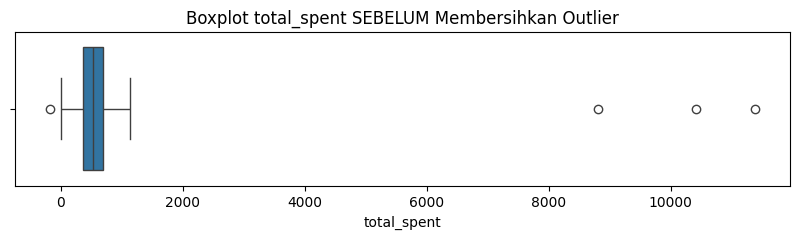

In [21]:
print("--- 3. Menangani Outlier 'total_spent' ---")

plt.figure(figsize=(10, 2))
sns.boxplot(x=df['total_spent'])
plt.title('Boxplot total_spent SEBELUM Membersihkan Outlier')
plt.show()

Menggunakan metode IQR (Interquartile Range) untuk mengidentifikasi outlier secara statistik.

In [22]:
# Hitung Q1, Q3, dan IQR
Q1 = df["total_spent"].quantile(0.25)
Q3 = df["total_spent"].quantile(0.75)
IQR = Q3 - Q1

# Tentukan Batas Bawah dan Batas Atas
batas_bawah = Q1 - (1.5 * IQR)
batas_atas = Q3 + (1.5 * IQR)

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Batas Bawah Outlier: {batas_bawah:.2f}")
print(f"Batas Atas Outlier: {batas_atas:.2f}")

Q1: 364.39, Q3: 695.0975, IQR: 330.7075
Batas Bawah Outlier: -131.67
Batas Atas Outlier: 1191.16


In [23]:
# Simpan jumlah data sebelum difilter
data_awal_count = df.shape[0]

# Filter data (membuat dataframe baru)
df_cleaned = df[(df["total_spent"] >= batas_bawah) & (df["total_spent"] <= batas_atas)].copy()

data_cleaned_count = df_cleaned.shape[0]
outlier_count = data_awal_count - data_cleaned_count

print(f"Jumlah data awal: {data_awal_count}")
print(f"Jumlah data setelah membersihkan outlier: {data_cleaned_count}")
print(f"Jumlah outlier yang dihapus: {outlier_count}")

Jumlah data awal: 100
Jumlah data setelah membersihkan outlier: 96
Jumlah outlier yang dihapus: 4


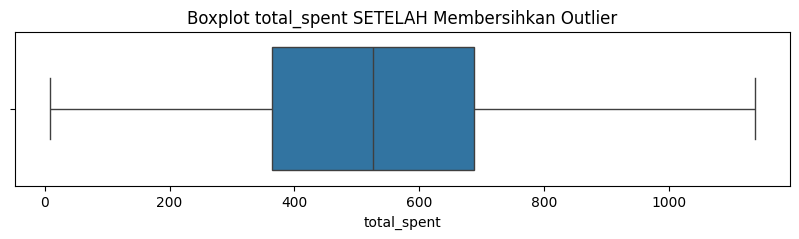

Data cleaning selesai. Data bersih disimpan di df_cleaned.


In [25]:
# Visualisasi Boxplot SETELAH membersihkan outlier
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_cleaned['total_spent'])
plt.title('Boxplot total_spent SETELAH Membersihkan Outlier')
plt.show()

print("Data cleaning selesai. Data bersih disimpan di df_cleaned.")

Visualisasi untuk Menjawab Pertanyaan Bisnis


--- 4. Membuat Visualisasi ---


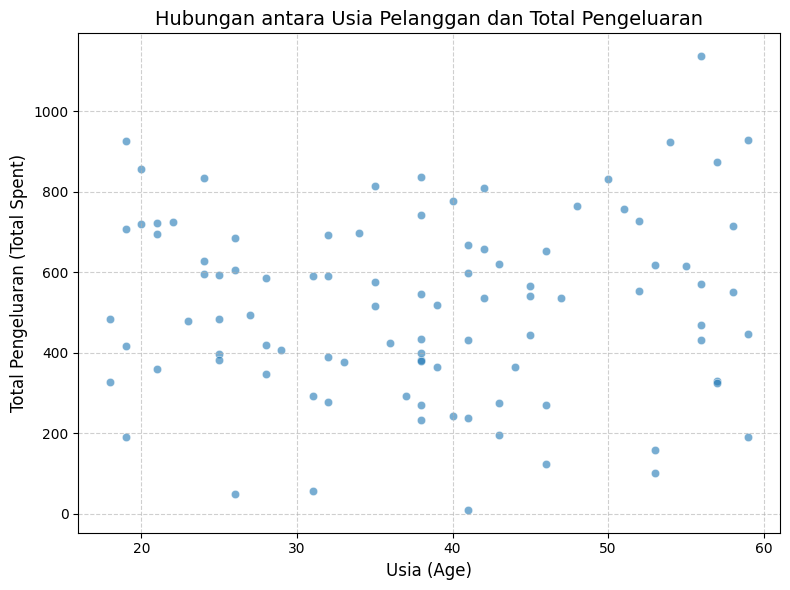

In [ ]:
print("\n--- 4. Membuat Visualisasi ---")

# a. Apakah terdapat hubungan antara age dan total_spent?
# Jenis Visualisasi: Scatter Plot
# Alasan: Scatter plot ideal untuk melihat korelasi/pola antara dua variabel numerik.
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cleaned, x='age', y='total_spent', alpha=0.6)
plt.title('Hubungan antara Usia Pelanggan dan Total Pengeluaran', fontsize=14)
plt.xlabel('Usia (Age)', fontsize=12)
plt.ylabel('Total Pengeluaran (Total Spent)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


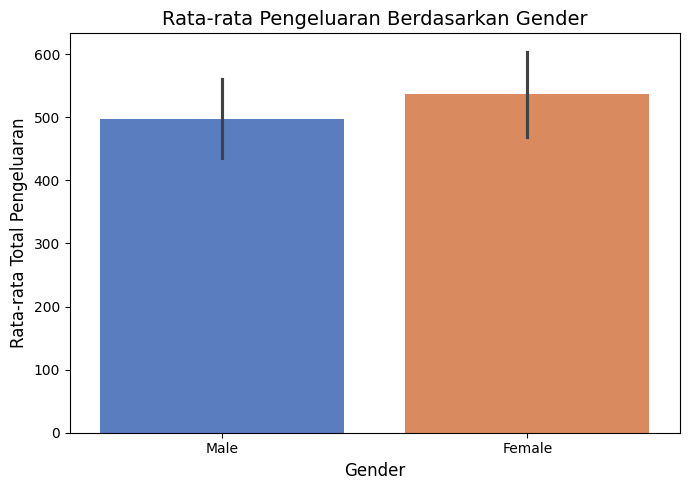

Visualisasi 2 (Bar Plot) disimpan sebagai 'barplot_gender_vs_spent.png'


In [30]:
# b. Apakah rata-rata pengeluaran berbeda berdasarkan gender?
# Jenis Visualisasi: Bar Plot
# Alasan: Bar plot sangat efektif untuk membandingkan nilai agregat (seperti rata-rata)
# antar grup/kategori yang berbeda.
plt.figure(figsize=(7, 5))
# Seaborn barplot secara default menghitung rata-rata (estimator=mean)
sns.barplot(data=df_cleaned, x='gender', y='total_spent', hue='gender', palette='muted', legend=False)
plt.title('Rata-rata Pengeluaran Berdasarkan Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Rata-rata Total Pengeluaran', fontsize=12)
plt.tight_layout()
plt.savefig('barplot_gender_vs_spent.png')
plt.show()
print("Visualisasi 2 (Bar Plot) disimpan sebagai 'barplot_gender_vs_spent.png'")